# Hash tables and the CPU cache

Comparing two ways of handling collisions in a hash table:

- **open addressing** with linear probing (in which every entry basically lives in one big array)
- **separate chaining** (each bucket points to a linked list of nodes)

The question we are facingn isn't "which one does fewer operations" (they're similar on paper), but
"which is friendlier to the cache" and on a real computer.

We have designed **two** experiments:

1. **Timing real tables.** Open addressing stores its keys in one contiguous array;
   chaining uses lots of little node objects scattered around the heap. The cache effect
   shows through.
2. **A cache simulator.** We record the exact sequence of memory addresses each table
   would touch and then run that sequence through a small and tiny cache model that just counts hits and also the misses. So we have no interpreter noise and we expect that the real difference comes out clean.


In [ ]:
%matplotlib inline
import time
import random
import gc                         # we pause garbage collection during timed runs
from array import array          # contiguous primitive storage
import numpy as np
import matplotlib.pyplot as plt

# Comment to consider: we know that on modern x86/ARM chip, a cache line is 64 bytes, So touching one byte
# actually drags in almost 64 neighbouring bytes for us and at free. That single fact is the
# reason contiguous data structures win.
LINE_BYTES = 64

random.seed(0)
np.random.seed(0)

## The two data structures

In [ ]:
class LinearProbingTable:
    """Open addressing. All keys live in one contiguous array. On a collision
    we just walk forward to the next slot. So that means that we are mostly stay inside
    the same cache line."""

    EMPTY = -1  # our keys are all >= 0, so -1 is a safe marker for us

    def __init__(self, capacity):
        self.capacity = capacity
        self.keys = array('q', [self.EMPTY]) * capacity
        self.values = array('q', [self.EMPTY]) * capacity

    def insert(self, key, value):
        # Capacity is a power of two. That means "key % capacity" only looks at the low
        # bits. Our keys are random and that should be fine and ok for as a simple hash.
        i = key % self.capacity
        while self.keys[i] != self.EMPTY and self.keys[i] != key:
            i += 1
            if i == self.capacity:
                i = 0
        self.keys[i] = key
        self.values[i] = value

    def lookup(self, key):
        i = key % self.capacity
        k = self.keys[i]               # Here we read the slot once and then reuse it below
        while k != self.EMPTY:
            if k == key:
                return self.values[i]
            i += 1
            if i == self.capacity:
                i = 0
            k = self.keys[i]
        return None

In [ ]:
class Node:
    # One linked-list node. The important thing is that every Node is its own
    # object allocated whenever it's inserted, so two nodes that end up in the
    # same bucket are usually pretty far apart in memory. That's what costs us the misses.
    def __init__(self, key, value):
        self.key = key
        self.value = value
        self.next = None


class ChainingTable:
    """Separate chaining. The bucket array is contiguous. But we know that if we following a chain
    that means we are hopping between scattered node objects."""

    def __init__(self, capacity):
        self.capacity = capacity
        self.buckets = [None] * capacity  # each entry is basically the head of a chain

    def insert(self, key, value):
        i = key % self.capacity
        node = self.buckets[i]
        while node is not None:
            if node.key == key:
                node.value = value
                return
            node = node.next
        # if not found, then we add a fresh node at the front of the chain
        new_node = Node(key, value)
        new_node.next = self.buckets[i]
        self.buckets[i] = new_node

    def lookup(self, key):
        node = self.buckets[key % self.capacity]
        while node is not None:
            if node.key == key:
                return node.value
            node = node.next
        return None

## Experiment 1: time real lookups

As the table grows it stops fitting in L1, then L2, then L3. We want to watch chaining
fall behind once the data spills out of the small caches. I need to mention that we also sweep the load factor,
where open addressing is expected to suffer from clustering.

In [ ]:
def make_keys(n):
    # n random keys. We kept the range pretty big and kinda enormous compared to n. This helps us accidental
    # duplicates basically never to happen.
    return np.random.randint(0, 2**60, size=n, dtype=np.int64)

def time_lookups(table, lookup_keys, repeats=5):
    # Time the whole batch a few times and keep the fastest run.
    best = None
    gc.disable()
    try:
        for _ in range(repeats):
            start = time.perf_counter()
            for k in lookup_keys:
                table.lookup(k)
            elapsed = time.perf_counter() - start
            if best is None or elapsed < best:
                best = elapsed
    finally:
        gc.enable()
    return best / len(lookup_keys) * 1e9  # nanoseconds per lookup

### 1a. Lookup time vs table size (load factor 0.7)

Small tables fit in cache. So the lighter per-operation cost wins. Once the table outgrows
the cache, we expect taht the locality of open addressing let it overtake chaining.

cap=2^12  OA key array=      32 KB   open addr= 938.1 ns   chaining= 438.1 ns   (chaining 0.47x slower)
cap=2^14  OA key array=     128 KB   open addr=1453.8 ns   chaining=1465.3 ns   (chaining 1.01x slower)
cap=2^16  OA key array=     512 KB   open addr=1210.8 ns   chaining= 689.3 ns   (chaining 0.57x slower)
cap=2^18  OA key array=    2048 KB   open addr= 623.1 ns   chaining= 736.3 ns   (chaining 1.18x slower)
cap=2^20  OA key array=    8192 KB   open addr= 667.4 ns   chaining= 573.6 ns   (chaining 0.86x slower)
cap=2^21  OA key array=   16384 KB   open addr= 676.0 ns   chaining= 617.3 ns   (chaining 0.91x slower)
cap=2^22  OA key array=   32768 KB   open addr= 703.4 ns   chaining= 673.9 ns   (chaining 0.96x slower)
cap=2^23  OA key array=   65536 KB   open addr= 714.7 ns   chaining= 847.2 ns   (chaining 1.19x slower)


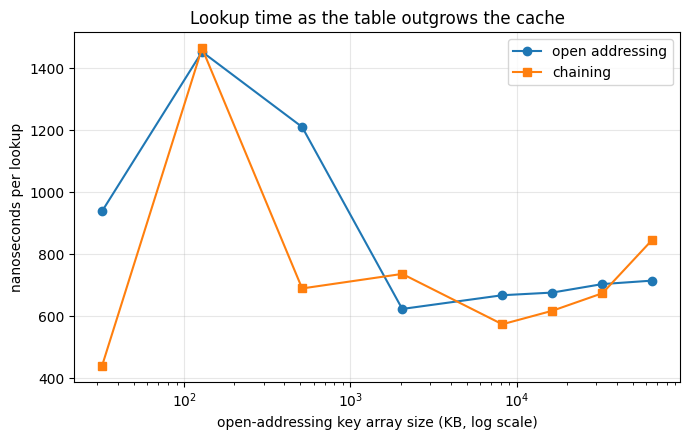

In [ ]:
capacities = [2**12, 2**14, 2**16, 2**18, 2**20, 2**21, 2**22, 2**23]
load_factor = 0.7
num_lookups = 80_000

oa_times, ch_times = [], []
for cap in capacities:
    n = int(cap * load_factor)
    keys = make_keys(n)

    oa = LinearProbingTable(cap)
    ch = ChainingTable(cap)
    for k in keys:
        k = int(k)  # plain Python int, used the same way for both tables
        oa.insert(k, k)
        ch.insert(k, k)

    # Look up keys that really are in the table (sampled with replacement).
    picks = np.random.randint(0, n, size=num_lookups)
    lookup_list = [int(keys[i]) for i in picks]

    oa_ns = time_lookups(oa, lookup_list)
    ch_ns = time_lookups(ch, lookup_list)
    oa_times.append(oa_ns)
    ch_times.append(ch_ns)

    oa_array_kb = cap * 8 / 1024  # size of just the open-addressing key array
    print(f"cap=2^{int(np.log2(cap)):<2}  OA key array={oa_array_kb:8.0f} KB"
          f"   open addr={oa_ns:6.1f} ns   chaining={ch_ns:6.1f} ns"
          f"   (chaining {ch_ns / oa_ns:.2f}x slower)")

plt.figure(figsize=(7, 4.5))
plt.plot([c * 8 / 1024 for c in capacities], oa_times, "o-", label="open addressing")
plt.plot([c * 8 / 1024 for c in capacities], ch_times, "s-", label="chaining")
plt.xscale("log")
plt.xlabel("open-addressing key array size (KB, log scale)")
plt.ylabel("nanoseconds per lookup")
plt.title("Lookup time as the table outgrows the cache")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 1b. Lookup time vs load factor (capacity 2^20)

Here we fix a biggish table and crank the load factor up. We expect that the open addressing start to suffer
as it fills and start giving back some of its advantage, while the chaining stays almost flat.

load=0.50   open addr= 570.2 ns   chaining= 782.2 ns
load=0.60   open addr= 609.8 ns   chaining= 581.1 ns
load=0.70   open addr=1211.8 ns   chaining= 863.0 ns
load=0.80   open addr= 813.2 ns   chaining= 625.0 ns
load=0.90   open addr=1235.5 ns   chaining= 651.2 ns
load=0.95   open addr=2255.2 ns   chaining=1013.8 ns


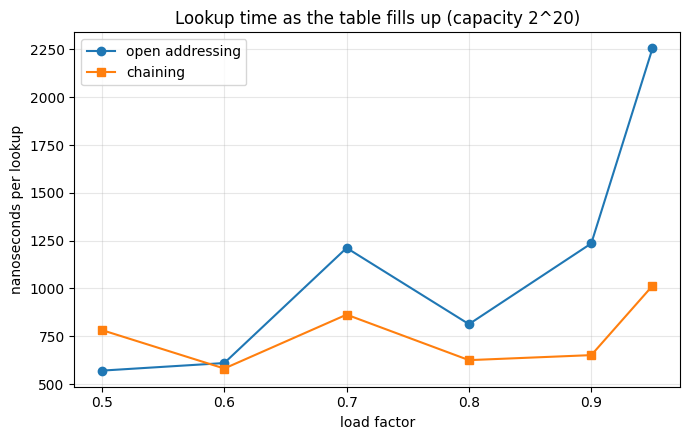

In [ ]:
cap = 2**20
load_factors = [0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
num_lookups = 80_000

oa_lf, ch_lf = [], []
for lf in load_factors:
    n = int(cap * lf)
    keys = make_keys(n)

    oa = LinearProbingTable(cap)
    ch = ChainingTable(cap)
    for k in keys:
        k = int(k)
        oa.insert(k, k)
        ch.insert(k, k)

    picks = np.random.randint(0, n, size=num_lookups)
    lookup_list = [int(keys[i]) for i in picks]

    oa_ns = time_lookups(oa, lookup_list)
    ch_ns = time_lookups(ch, lookup_list)
    oa_lf.append(oa_ns)
    ch_lf.append(ch_ns)
    print(f"load={lf:.2f}   open addr={oa_ns:6.1f} ns   chaining={ch_ns:6.1f} ns")

plt.figure(figsize=(7, 4.5))
plt.plot(load_factors, oa_lf, "o-", label="open addressing")
plt.plot(load_factors, ch_lf, "s-", label="chaining")
plt.xlabel("load factor")
plt.ylabel("nanoseconds per lookup")
plt.title("Lookup time as the table fills up (capacity 2^20)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Experiment 2: a tiny cache simulator

Wall-clock time in Python is mostly interpreter overhead. so here, we measure the thing we
actually care about directly and that is cache misses. We record the sequence of memory addresses each
table touches during lookups and feed it through a small set-associative cache model that
only counts hits and misses.

In [ ]:
class Cache:

    def __init__(self, size_bytes, ways=8, line_bytes=LINE_BYTES):
        self.line_bytes = line_bytes
        self.ways = ways
        num_lines = size_bytes // line_bytes
        self.num_sets = max(1, num_lines // ways)
        self.sets = [[] for _ in range(self.num_sets)]
        self.hits = 0
        self.misses = 0

    def access(self, address):
        line = address // self.line_bytes
        s = line % self.num_sets
        bucket = self.sets[s]
        if line in bucket:
            self.hits += 1
            bucket.remove(line)
            bucket.insert(0, line)
        else:
            self.misses += 1
            bucket.insert(0, line)
            if len(bucket) > self.ways:
                bucket.pop()

    def miss_rate(self):
        total = self.hits + self.misses
        return self.misses / total if total else 0.0

In [ ]:
OA_BASE = 0
BUCKET_BASE = 1 << 40
NODE_BASE = 1 << 50

SLOT_BYTES = 8    # one 8 bite key per open-addressing slot
PTR_BYTES = 8     # one 8 bite head pointer per bucket
NODE_BYTES = 32


def build_open_addressing_slots(capacity, keys):
    # Replay the inserts so we know which key ends up in which slot.
    table = [-1] * capacity
    for k in keys:
        i = k % capacity
        while table[i] != -1 and table[i] != k:
            i = (i + 1) % capacity
        table[i] = k
    return table


def open_addressing_trace(table, capacity, lookup_keys):

    for k in lookup_keys:
        i = k % capacity
        while True:
            yield OA_BASE + i * SLOT_BYTES
            if table[i] == k or table[i] == -1:
                break
            i = (i + 1) % capacity


def build_chaining_nodes(capacity, keys):

    heads = [None] * capacity
    addr, key, nxt = [], [], []
    free = NODE_BASE
    for k in keys:
        nid = len(addr)
        addr.append(free)
        free += NODE_BYTES
        key.append(k)
        nxt.append(heads[k % capacity])
        heads[k % capacity] = nid
    return heads, addr, key, nxt


def chaining_trace(heads, addr, key, nxt, capacity, lookup_keys):
    for k in lookup_keys:
        i = k % capacity
        yield BUCKET_BASE + i * PTR_BYTES   # read the bucket's head pointer
        nid = heads[i]
        while nid is not None:
            yield addr[nid]                 # then jump to the node itself
            if key[nid] == k:
                break
            nid = nxt[nid]


def run_through_cache(trace, size_bytes, ways=8):
    cache = Cache(size_bytes, ways=ways)
    for address in trace:
        cache.access(address)
    return cache.miss_rate()

### 2a. Miss rate by cache level

One table, three cache sizes standing in for L1 / L2 / L3.

L1 (32 KB)    open addr miss= 48.8%   chaining miss= 97.8%
L2 (256 KB)   open addr miss= 25.4%   chaining miss= 83.7%
L3 (8 MB)     open addr miss= 11.9%   chaining miss= 36.9%


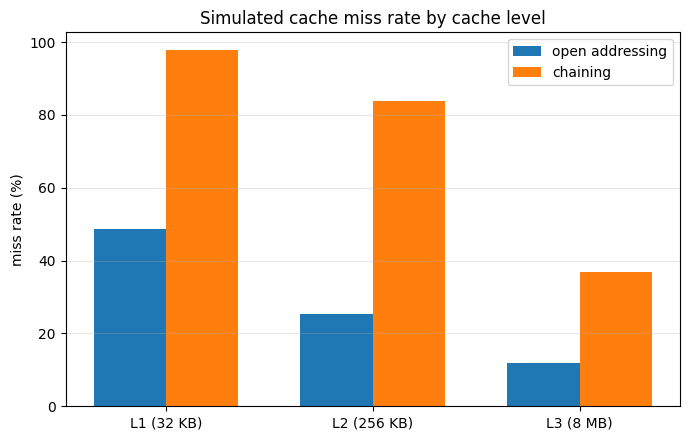

In [ ]:
capacity = 2**16
load_factor = 0.7
n = int(capacity * load_factor)
keys = [int(x) for x in make_keys(n)]
lookups = [keys[i] for i in np.random.randint(0, n, size=30_000)]

table = build_open_addressing_slots(capacity, keys)
heads, addr, key, nxt = build_chaining_nodes(capacity, keys)

levels = [("L1 (32 KB)", 32 * 1024, 8),
          ("L2 (256 KB)", 256 * 1024, 8),
          ("L3 (8 MB)", 8 * 1024 * 1024, 16)]

labels, oa_lvl, ch_lvl = [], [], []
for name, size, ways in levels:
    oa = run_through_cache(open_addressing_trace(table, capacity, lookups), size, ways)
    ch = run_through_cache(chaining_trace(heads, addr, key, nxt, capacity, lookups), size, ways)
    labels.append(name)
    oa_lvl.append(oa * 100)
    ch_lvl.append(ch * 100)
    print(f"{name:12s}  open addr miss={oa * 100:5.1f}%   chaining miss={ch * 100:5.1f}%")

x = np.arange(len(labels))
width = 0.35
plt.figure(figsize=(7, 4.5))
plt.bar(x - width / 2, oa_lvl, width, label="open addressing")
plt.bar(x + width / 2, ch_lvl, width, label="chaining")
plt.xticks(x, labels)
plt.ylabel("miss rate (%)")
plt.title("Simulated cache miss rate by cache level")
plt.legend()
plt.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

### 2b. Miss rate vs table size (fixed L2-sized cache)

Fix the cache and grow the table. We want to see which scheme spills out of the cache first.

table key array=     32 KB   open addr miss=  1.2%   chaining miss=  4.1%
table key array=     64 KB   open addr miss=  2.4%   chaining miss=  8.3%
table key array=    128 KB   open addr miss=  4.6%   chaining miss= 42.8%
table key array=    256 KB   open addr miss=  9.0%   chaining miss= 69.6%
table key array=    512 KB   open addr miss= 27.9%   chaining miss= 84.2%
table key array=   1024 KB   open addr miss= 38.7%   chaining miss= 91.8%


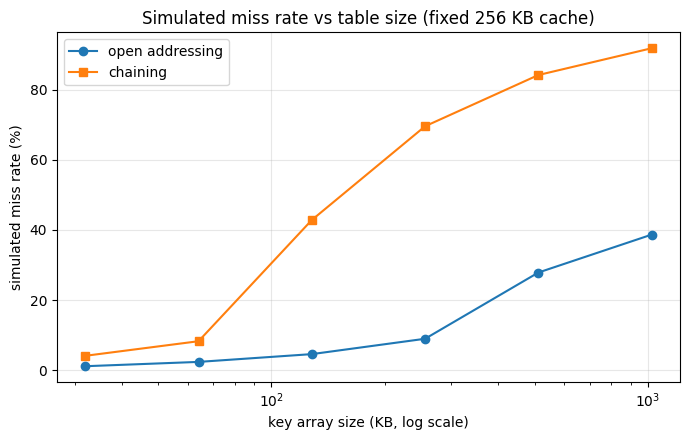

In [ ]:
capacities = [2**12, 2**13, 2**14, 2**15, 2**16, 2**17]
load_factor = 0.7
cache_size = 256 * 1024

sizes_kb, oa_sz, ch_sz = [], [], []
for cap in capacities:
    n = int(cap * load_factor)
    keys = [int(x) for x in make_keys(n)]
    lookups = [keys[i] for i in np.random.randint(0, n, size=20_000)]

    table = build_open_addressing_slots(cap, keys)
    heads, addr, key, nxt = build_chaining_nodes(cap, keys)

    oa = run_through_cache(open_addressing_trace(table, cap, lookups), cache_size)
    ch = run_through_cache(chaining_trace(heads, addr, key, nxt, cap, lookups), cache_size)

    sizes_kb.append(cap * 8 / 1024)
    oa_sz.append(oa * 100)
    ch_sz.append(ch * 100)
    print(f"table key array={cap * 8 / 1024:7.0f} KB"
          f"   open addr miss={oa * 100:5.1f}%   chaining miss={ch * 100:5.1f}%")

plt.figure(figsize=(7, 4.5))
plt.plot(sizes_kb, oa_sz, "o-", label="open addressing")
plt.plot(sizes_kb, ch_sz, "s-", label="chaining")
plt.xscale("log")
plt.xlabel("key array size (KB, log scale)")
plt.ylabel("simulated miss rate (%)")
plt.title("Simulated miss rate vs table size (fixed 256 KB cache)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

***

⚽